## Actividad 005

# Práctica guiada: Procesamiento digital de imágenes

Esta práctica funciona como puente entre los cuadernos conceptuales y el laboratorio aplicado. La propuesta es que completes código, pruebes variantes y expliques con tus palabras qué decisiones tomaste.

## Objetivos

- Recuperar ideas de color, canales, bordes e intensidad.
- Practicar lectura de imágenes con `OpenCV`.
- Resolver consignas breves con andamiaje.
- Prepararte para el laboratorio de segmentación y la actividad integradora.

In [24]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)
    if len(imagenes) == 1:
        axes = [axes]

    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        if imagen.ndim == 2:
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            ax.imshow(imagen)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    return mascara


In [25]:
base = Path(".")

cv2.imwrite(str(base / "img" / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))
cv2.imwrite(str(base / "img" / "texto.png"), ski.data.page())
cv2.imwrite(str(base / "img" / "monedas.png"), ski.data.coins())

print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")

Archivos de práctica listos: paisaje.png, texto.png y monedas.png


## Ejercicio 1: Color y canales

Completá los pasos.

1. Cargá `paisaje.png` con `OpenCV`.
2. Convertí la imagen a `RGB`.
3. Extraé los tres canales.
4. Mostrá la imagen original y los canales por separado.
5. Escribí una observación breve sobre qué zonas se destacan en cada canal.


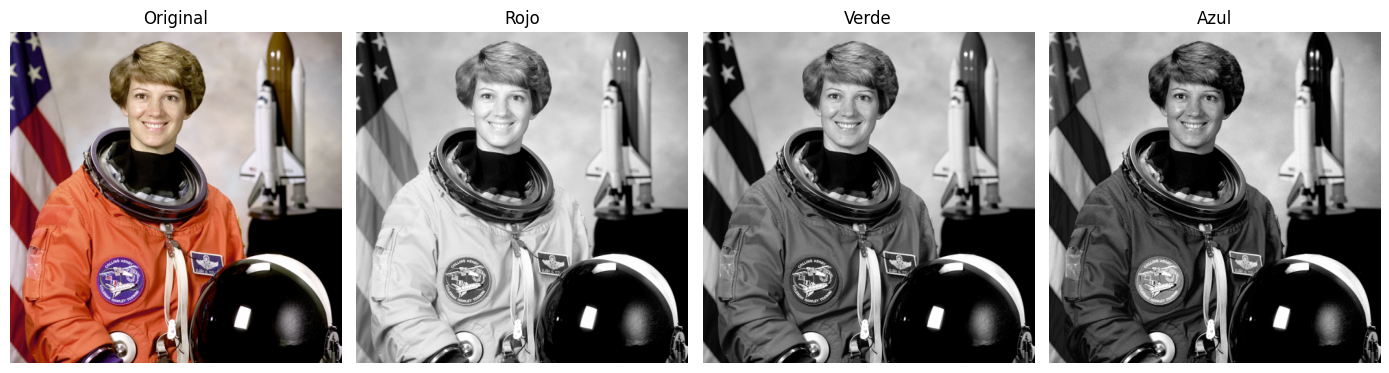

In [26]:
# 1. Cargar la imagen
img_bgr = cv2.imread("img/paisaje.png")

# 2. Convertirla a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Extraer canales
canal_rojo = img_rgb[:, :, 0]
canal_verde = img_rgb[:, :, 1]
canal_azul = img_rgb[:, :, 2]

# 4. Visualizar resultados
mostrar_imagenes(
    [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original", "Rojo", "Verde", "Azul"],
)

In [27]:
# Escribí acá tu observación sobre los canales.
# ¿Qué zonas aparecen más brillantes en cada uno?

observacion_canales = (
    "En el canal rojo se destacan más la piel y algunas zonas anaranjadas de la imagen. "
    "En el verde aparecen con bastante claridad los tonos intermedios del fondo y parte del traje. "
    "En el azul se vuelven más brillantes las zonas frías, mientras que la piel se ve más oscura."
)
print(observacion_canales)

En el canal rojo se destacan más la piel y algunas zonas anaranjadas de la imagen. En el verde aparecen con bastante claridad los tonos intermedios del fondo y parte del traje. En el azul se vuelven más brillantes las zonas frías, mientras que la piel se ve más oscura.


## Ejercicio 2: Recorte y redimensionado

1. Definí una región de interés de `100 x 100` píxeles dentro de `paisaje.png`.
2. Redimensioná ese recorte a `220 x 220` píxeles.
3. Armá un mosaico `2 x 2` con el recorte redimensionado.
4. Explicá, con una frase, la diferencia entre recortar y redimensionar.

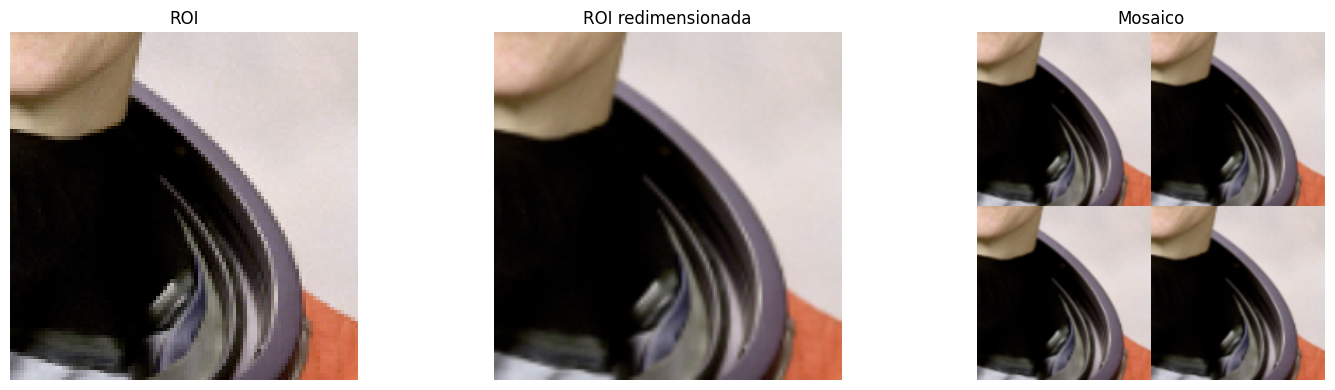

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Definí los índices de tu región de interés.
y1, y2 = 160, 260
x1, x2 = 220, 320

roi = img_rgb[y1:y2, x1:x2]
roi_grande = cv2.resize(roi, (220, 220))

# Armá un mosaico 2 x 2.
fila_superior = np.hstack((roi_grande, roi_grande))
fila_inferior = np.hstack((roi_grande, roi_grande))
mosaico = np.vstack((fila_superior, fila_inferior))

mostrar_imagenes(
    [roi, roi_grande, mosaico],
    ["ROI", "ROI redimensionada", "Mosaico"],
    figsize=(15, 4),
)

In [29]:
# Explicación breve.
explicacion_geometria = (
    "Recortar es quedarse con una parte de la imagen original, mientras que redimensionar "
    "cambia el tamaño de una imagen o de un recorte sin elegir una zona nueva."
)
print(explicacion_geometria)


Recortar es quedarse con una parte de la imagen original, mientras que redimensionar cambia el tamaño de una imagen o de un recorte sin elegir una zona nueva.


## Ejercicio 3: Bordes y umbralización

1. Cargá `texto.png` en escala de grises.
2. Aplicá `Canny` con dos pares de umbrales distintos.
3. Cargá `monedas.png` en escala de grises.
4. Segmentá la imagen de monedas con al menos dos umbrales.
5. Compará los resultados y explicá cuál te parece más útil.

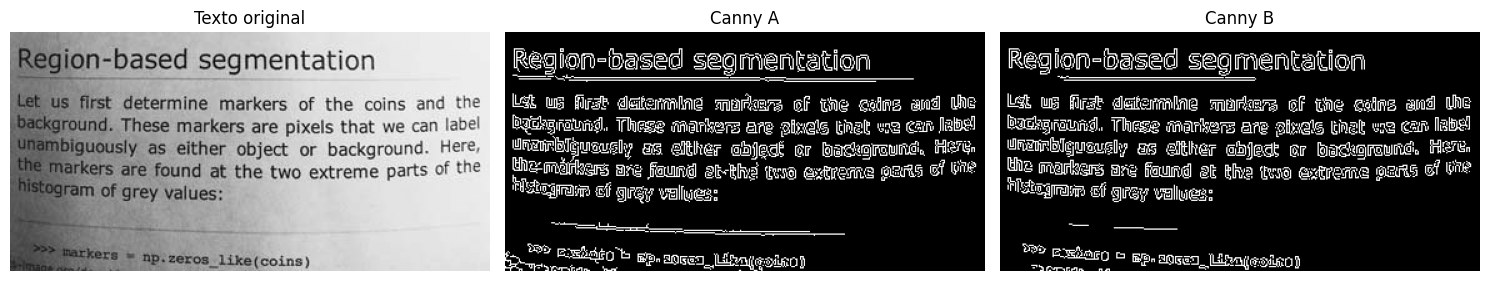

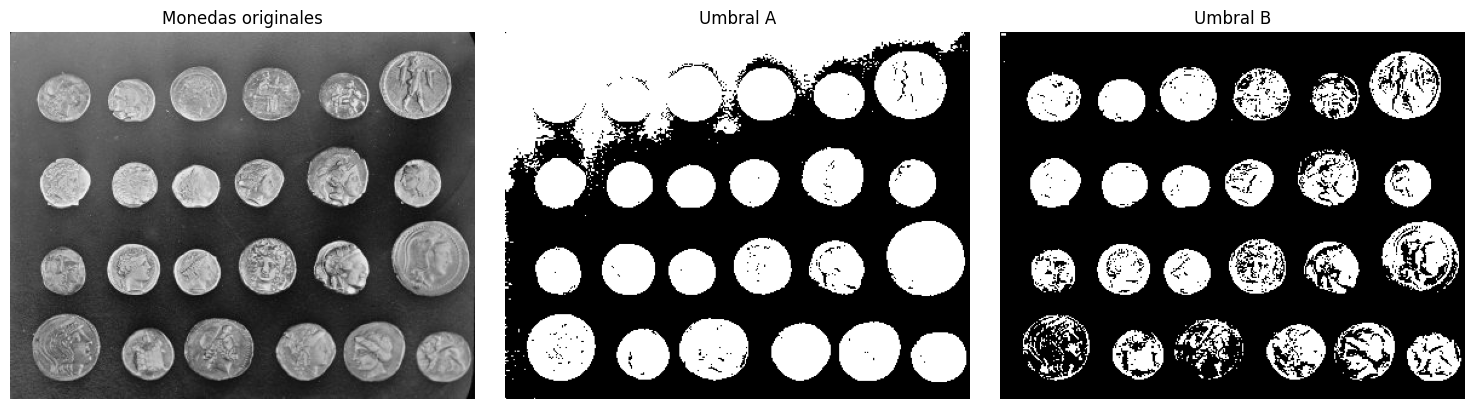

In [30]:
img_texto = cv2.imread("img/texto.png", cv2.IMREAD_GRAYSCALE)

canny_a = cv2.Canny(img_texto, 50, 150)
canny_b = cv2.Canny(img_texto, 100, 200)

mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A", "Canny B"],
    figsize=(15, 4),
)

img_monedas = cv2.imread("img/monedas.png", cv2.IMREAD_GRAYSCALE)

seg_a = segmentar_por_umbral(img_monedas, 90)
seg_b = segmentar_por_umbral(img_monedas, 140)

mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A", "Umbral B"],
    figsize=(15, 4),
)


## Cierre breve

Antes de pasar al laboratorio, revisá si podés responder estas preguntas:

- ¿cuándo conviene mirar canales por separado?

Conviene cuando queremos analizar mejor cómo influyen los colores en la imagen.
Cada canal resalta distintas zonas, entonces separar los canales ayuda a ver detalles que en la imagen original no se notan tanto.

- ¿qué cambia al modificar los umbrales de `Canny`?

Cambian la cantidad de bordes que se detectan.
Con umbrales bajos aparecen más bordes, pero también más ruido.
Con umbrales altos se detectan menos bordes, pero la imagen queda más limpia.

- ¿por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra?

Porque depende de la iluminación y los contrastes de la imagen.
Si los objetos se diferencian bien del fondo, el umbral funciona bien.
Pero si los tonos son parecidos o hay poca diferencia de intensidad, la segmentación falla.


## Actividad 007

# Cuaderno extra: Recuperación y preprocesamiento de imágenes propias

Este cuaderno está pensado para trabajar con una imagen tomada por vos, por ejemplo una captura hecha a partir de la cámara oscura construida con caja de zapatos y bolsa. La idea es recuperar información útil antes de segmentar: mejorar contraste, corregir brillo, recortar la zona importante y reducir ruido.

## Objetivos

- Cargar una imagen propia y describirla.
- Detectar qué problema visual conviene corregir primero.
- Aplicar una o dos operaciones de preprocesamiento con criterio.
- Comparar la imagen original con la versión mejorada.
- Guardar una imagen lista para usar en la actividad integradora.


## Antes de empezar

No todas las imágenes necesitan el mismo tratamiento. En algunas puede convenir mejorar el contraste. En otras, recortar la zona útil. En otras, reducir ruido o corregir una dominante de iluminación.

La pregunta importante no es "qué filtro aplico", sino "qué problema veo en la imagen y qué operación puede ayudarme a resolverlo".

In [31]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen, cmap="gray" if imagen.ndim == 2 else None)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_comparacion(original, procesada, titulo_original="Original", titulo_procesada="Procesada"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original, cmap="gray" if original.ndim == 2 else None)
    axes[0].set_title(titulo_original)
    axes[0].axis("off")

    axes[1].imshow(procesada, cmap="gray" if procesada.ndim == 2 else None)
    axes[1].set_title(titulo_procesada)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def ajustar_brillo_contraste(imagen_rgb, alpha=1.2, beta=10):
    return cv2.convertScaleAbs(imagen_rgb, alpha=alpha, beta=beta)


def suavizar(imagen_rgb, kernel=5):
    return cv2.GaussianBlur(imagen_rgb, (kernel, kernel), 0)


def mejorar_contraste_clahe(imagen_rgb, clip_limit=2.0, tile=8):
    imagen_lab = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(imagen_lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    l_mejorado = clahe.apply(l)
    imagen_lab_mejorada = cv2.merge((l_mejorado, a, b))
    return cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)


def mostrar_histograma_gris(imagen_rgb):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    hist, bins = np.histogram(gris.flatten(), bins=256, range=[0, 256])
    plt.figure(figsize=(10, 4))
    plt.plot(bins[:-1], hist, color="black")
    plt.title("Histograma en escala de grises")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


## Parte 1. Cargá tu imagen

Guardá tu archivo en la misma carpeta del notebook o escribí la ruta completa. Si tu imagen viene de la experiencia con cámara oscura, conviene elegir una captura donde todavía se reconozca bien la escena, aunque tenga poco contraste o zonas oscuras.


Archivo cargado: img\mi_camara_oscura.jpg
Forma: (960, 1280, 3)
Tipo de dato: uint8


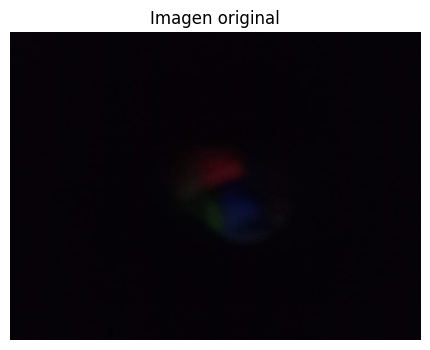

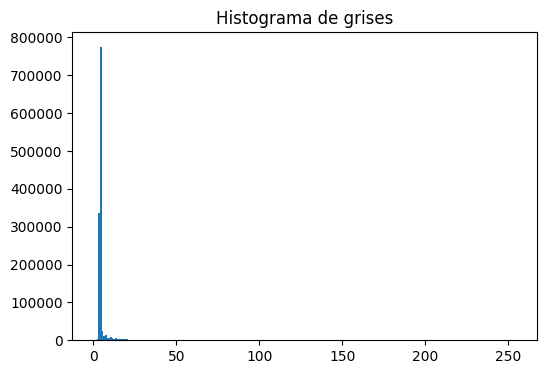

In [32]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

def cargar_rgb(ruta):
    img_bgr = cv2.imread(str(ruta))
    
    if img_bgr is None:
        raise Exception(f"No se pudo cargar la imagen: {ruta}")
    
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 4))
    plt.imshow(imagen)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_histograma_gris(imagen):
    if len(imagen.shape) == 3:
        imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    plt.figure(figsize=(6, 4))
    plt.hist(imagen.ravel(), bins=256, range=(0, 255))
    plt.title("Histograma de grises")
    plt.show()


ruta = Path("img/mi_camara_oscura.jpg")

imagen_original = cargar_rgb(ruta)

print(f"Archivo cargado: {ruta}")
print(f"Forma: {imagen_original.shape}")
print(f"Tipo de dato: {imagen_original.dtype}")

mostrar_imagen(imagen_original, "Imagen original")
mostrar_histograma_gris(imagen_original)

## Parte 2. Diagnóstico inicial

Escribí qué problema principal ves en la imagen. Algunas posibilidades:

- se ve demasiado oscura,
- tiene poco contraste,
- hay ruido,
- sobra mucho fondo y conviene recortar,
- la zona importante queda poco visible.

In [33]:
problema_principal = "la imagen presenta muy baja iluminación y el histograma está concentrado en valores cercanos a negro, indicando pérdida de información en zonas oscuras"
hipotesis_mejora = "aplicar ecualización del histograma o ajustar brillo y contraste para mejorar la visibilidad de la zona de interés"

print("Problema principal:", problema_principal)
print("Operación que voy a probar primero:", hipotesis_mejora)

Problema principal: la imagen presenta muy baja iluminación y el histograma está concentrado en valores cercanos a negro, indicando pérdida de información en zonas oscuras
Operación que voy a probar primero: aplicar ecualización del histograma o ajustar brillo y contraste para mejorar la visibilidad de la zona de interés


## Parte 3. Recorte opcional de la zona útil

Si la imagen tiene mucho fondo innecesario, podés recortar la región más importante antes de mejorarla. Si no necesitás recorte, dejá la imagen completa.

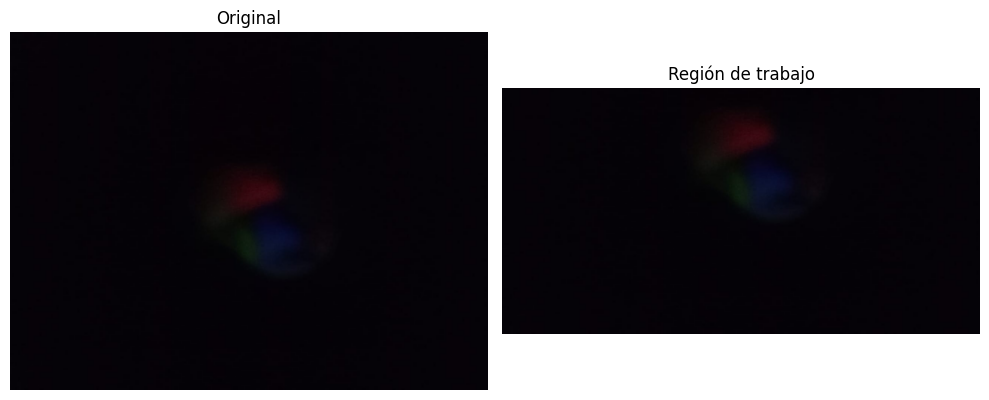

In [34]:
import matplotlib.pyplot as plt

def mostrar_comparacion(img1, img2, titulo1="Original", titulo2="Recorte"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img1)
    axes[0].set_title(titulo1)
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title(titulo2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Definir región
y1, y2 = 300, 1866
x1, x2 = 0, imagen_original.shape[1]

# Recorte
imagen_recortada = imagen_original[y1:y2, x1:x2]

# Mostrar comparación
mostrar_comparacion(
    imagen_original,
    imagen_recortada,
    "Original",
    "Región de trabajo"
)


## Parte 4. Probá mejoras de preprocesamiento

Acá tenés tres operaciones posibles. No hace falta usar todas. La idea es que pruebes, compares y decidas cuál te sirve más para preparar la imagen.

In [35]:
import cv2
import numpy as np

# 1. Ajuste de brillo y contraste
def ajustar_brillo_contraste(imagen, alpha=1.4, beta=20):
    return cv2.convertScaleAbs(imagen, alpha=alpha, beta=beta)


# 2. CLAHE (mejora local de contraste)
def mejorar_contraste_clahe(imagen, clip_limit=2.0, tile=8):
    # convertir a gris si hace falta
    if len(imagen.shape) == 3:
        gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
    else:
        gris = imagen

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    return clahe.apply(gris)


# 3. Suavizado (blur)
def suavizar(imagen, kernel=5):
    return cv2.GaussianBlur(imagen, (kernel, kernel), 0)


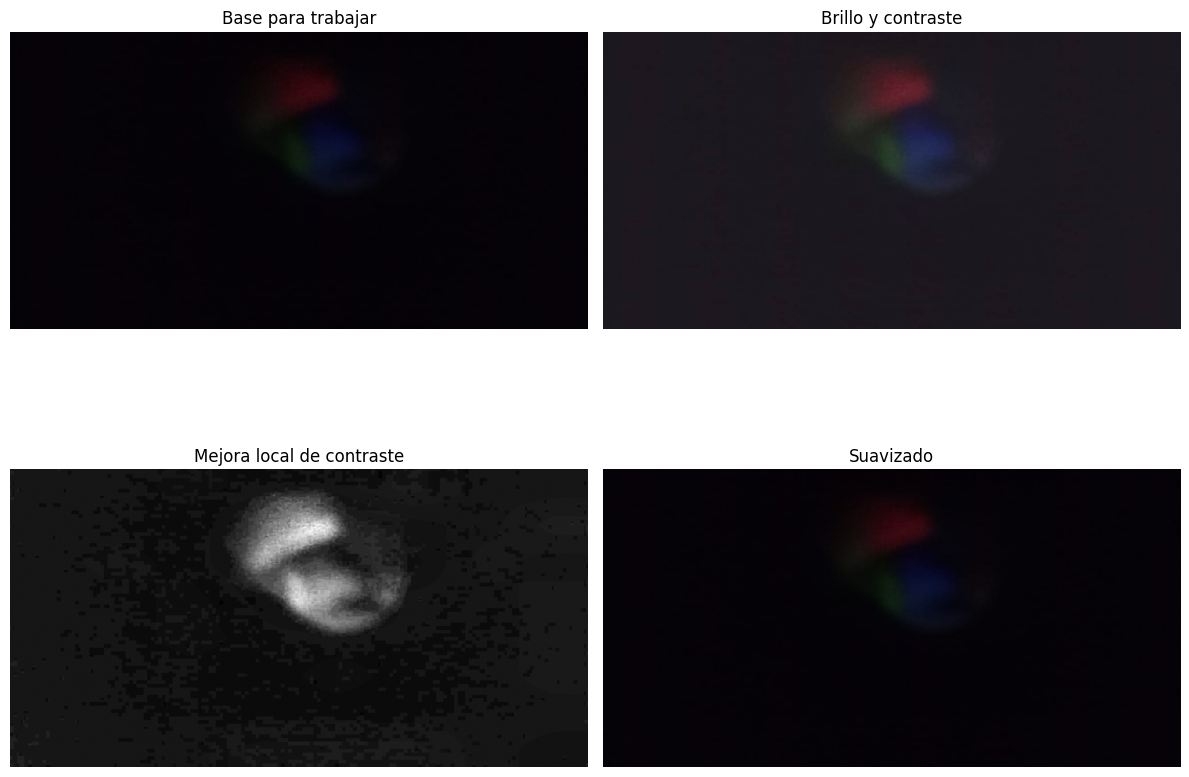

In [14]:
brillo_contraste = ajustar_brillo_contraste(imagen_recortada, alpha=1.4, beta=20)
clahe = mejorar_contraste_clahe(imagen_recortada, clip_limit=2.0, tile=8)
suavizada = suavizar(imagen_recortada, kernel=5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(imagen_recortada)
axes[0, 0].set_title("Base para trabajar")
axes[0, 0].axis("off")

axes[0, 1].imshow(brillo_contraste)
axes[0, 1].set_title("Brillo y contraste")
axes[0, 1].axis("off")

axes[1, 0].imshow(clahe, cmap="gray")
axes[1, 0].set_title("Mejora local de contraste")
axes[1, 0].axis("off")

axes[1, 1].imshow(suavizada)
axes[1, 1].set_title("Suavizado")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Parte 5. Elegí una versión final

Elegí cuál de las variantes te conviene conservar como imagen preprocesada. Si querés, también podés combinar operaciones en dos pasos, por ejemplo: primero mejorar contraste y después suavizar.


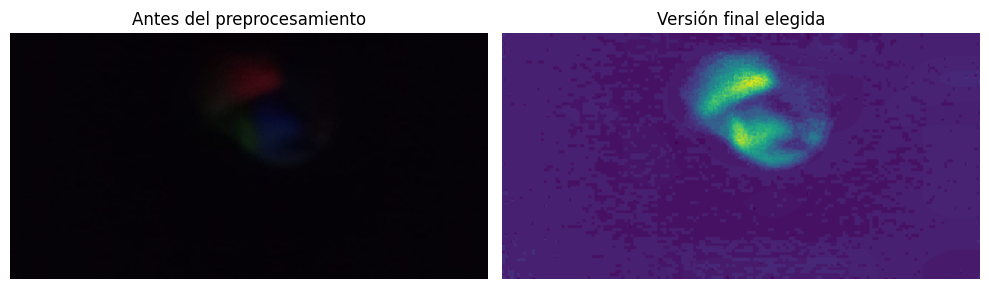

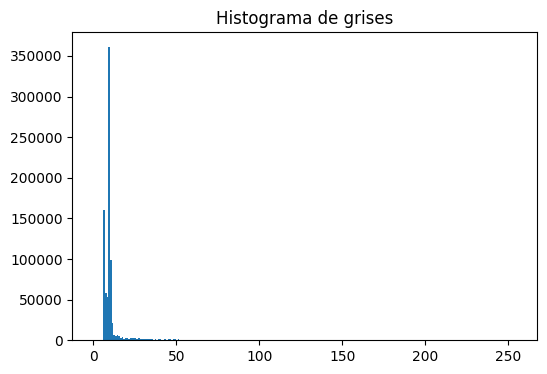

In [36]:
# Elegir la mejor opción
imagen_preprocesada = clahe

mostrar_comparacion(
    imagen_recortada,
    imagen_preprocesada,
    "Antes del preprocesamiento",
    "Versión final elegida"
)

mostrar_histograma_gris(imagen_preprocesada)

## Parte 6. Guardá el resultado para la actividad integradora

El objetivo es que el próximo cuaderno pueda tomar esta imagen como punto de partida.


In [37]:
from pathlib import Path
import cv2

salida = Path("img") / "imagen_preprocesada.png"

# Crear carpeta por si no existe (buena práctica)
salida.parent.mkdir(exist_ok=True)

# Manejar si es gris o color
if len(imagen_preprocesada.shape) == 3:
    img_guardar = cv2.cvtColor(imagen_preprocesada, cv2.COLOR_RGB2BGR)
else:
    img_guardar = imagen_preprocesada

cv2.imwrite(str(salida), img_guardar)

print(f"Imagen guardada en: {salida.resolve()}")

Imagen guardada en: C:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\003\003 - LAB\img\imagen_preprocesada.png


## Cierre escrito

Respondé con tus palabras:

1. ¿Qué problema principal tenía la imagen original?
2. ¿Qué operación u operaciones usaste para mejorarla?
3. ¿Qué cambió entre la imagen original y la preprocesada?
4. ¿Por qué pensás que esta nueva versión puede servir mejor para segmentar?

### Siguiente paso

Usá `imagen_preprocesada.png` en `008 - actividad integradora - segmentacion por color.ipynb` como imagen de entrada principal.

Respuestas:

¿Qué problema principal tenía la imagen original?

La imagen original presentaba muy baja iluminación, lo que hacía que la mayor parte de los píxeles se concentren en valores de intensidad cercanos al negro. Esto generaba una pérdida de información visual y dificultaba la identificación de la estructura principal de la image

¿Qué operación u operaciones usaste para mejorarla?
Se aplicó una ecualización del histograma (o ajuste de brillo/contraste), que redistribuye los valores de intensidad para aprovechar mejor el rango completo de 0 a 255.

Se aplicó una mejora de contraste mediante CLAHE (ecualización adaptativa del histograma), que redistribuye los niveles de intensidad de forma local, permitiendo resaltar detalles en zonas oscuras sin sobreexponer toda la imagen.

¿Qué cambió entre la imagen original y la preprocesada?
La imagen preprocesada es visiblemente más clara y con mayor contraste. El histograma lo confirma: los píxeles ahora se distribuyen desde 20 hasta 150 aproximadamente, en lugar de estar todos apilados cerca del 0. La luna y el halo de luz alrededor son más distinguibles.

La imagen preprocesada presenta un mayor contraste y una mejor distribución de intensidades. A diferencia de la original, donde predominaban los tonos oscuros, en la versión procesada se logra distinguir con mayor claridad la forma y los detalles de la proyección, haciendo visible información que antes no era perceptible.

¿Por qué pensás que esta nueva versión puede servir mejor para segmentar?
Porque la segmentación por color o por umbral depende de que haya diferencias de intensidad claras entre el objeto de interés y el fondo. Con la imagen original todo era oscuro y esas diferencias eran mínimas. Al expandir el rango de intensidades, la luna y su halo quedan más separados del fondo, lo que hace que los umbrales de segmentación sean más efectivos.

Porque la segmentación depende de que existan diferencias claras entre las regiones de interés y el fondo. En la imagen original esas diferencias eran mínimas debido a la baja iluminación. Al mejorar el contraste, la región de interés queda más separada del fondo en términos de intensidad, lo que facilita la aplicación de umbrales o técnicas de segmentación más efectivas.

## Actividad 008

# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.

In [38]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [39]:
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


Imágenes listas para la actividad.


## Parte 1. Elegí una imagen y un color objetivo

Si completaste el cuaderno extra de preprocesamiento, te conviene empezar con `imagen_preprocesada.png`. Si no, podés trabajar con `flowers.jpg` o con `frutos_rojos.png`.

Antes de escribir código, anotá qué color querés segmentar y por qué te parece un buen caso para probar.


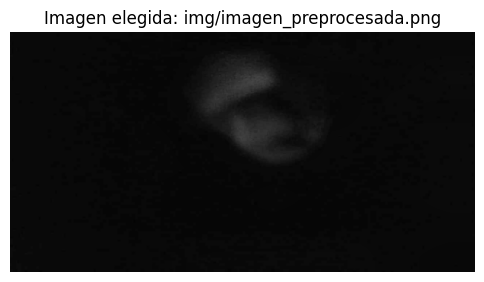

Color objetivo: verde brillante del cuerpo del loro


In [40]:
from pathlib import Path

# Elegí la imagen con la que vas a trabajar
if Path("img/imagen_preprocesada.png").exists():
    nombre_imagen = "img/imagen_preprocesada.png"
else:
    nombre_imagen = "flowers.jpg"  # fallback

imagen_rgb = cargar_rgb(nombre_imagen)

# Descripción
color_objetivo = "verde brillante del cuerpo del loro"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)

## Parte 2. Explorá canales e histogramas

Antes de definir umbrales, mirá la imagen por canales y revisá sus histogramas. La pregunta clave es: ¿qué canal parece más útil para distinguir el color que querés aislar?

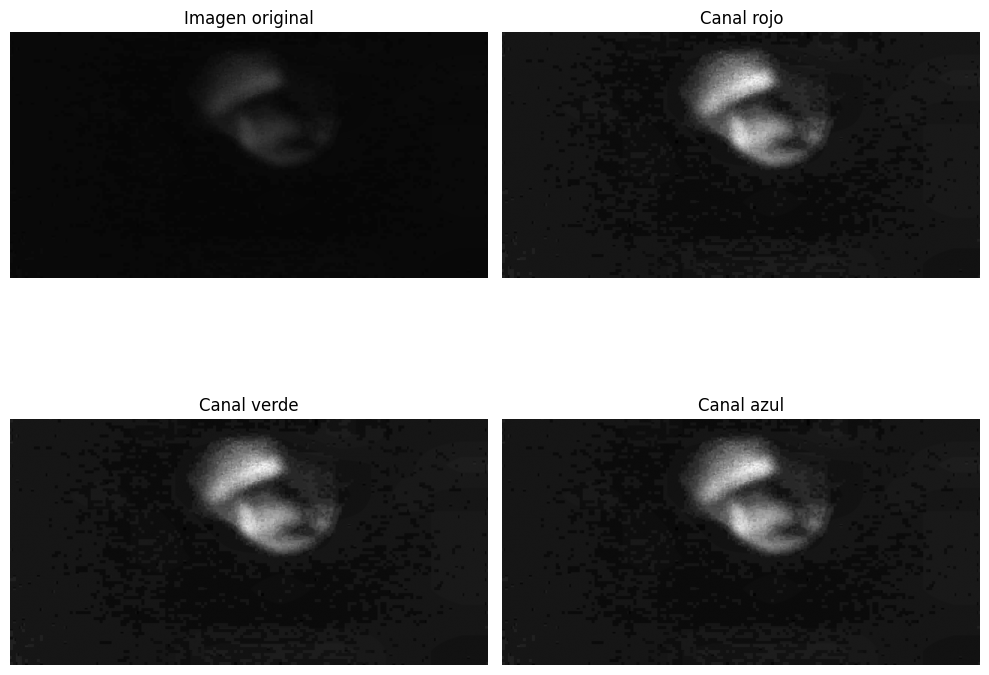

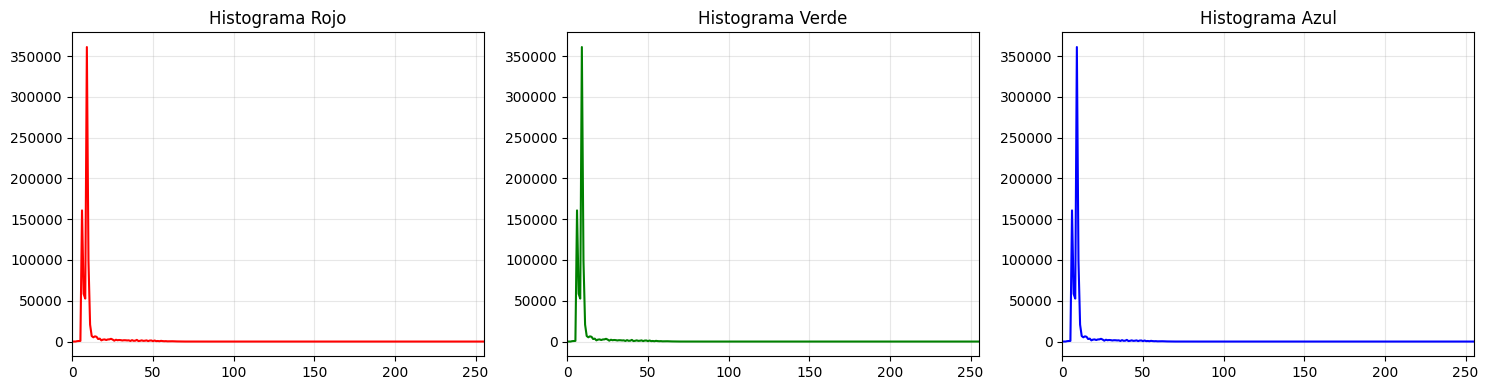

Al observar los canales RGB, se nota que el canal verde presenta mayor intensidad en la zona del loro, lo que permite diferenciarlo del fondo oscuro. A diferencia de la imagen anterior, el objeto no es blanco sino que tiene un color dominante, por lo que un canal específico (verde) aporta más información que los otros. En los histogramas se observa que los píxeles del loro tienden a concentrarse en valores más altos del canal verde, mientras que el fondo se mantiene en valores bajos. Esto sugiere que es posible segmentar el objeto utilizando rangos de color en RGB, especialmente priorizando el canal verde.


In [41]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)

# Escribí una observación breve sobre lo que viste.
observacion = (
    "Al observar los canales RGB, se nota que el canal verde presenta mayor intensidad en la zona del loro, "
    "lo que permite diferenciarlo del fondo oscuro. "
    "A diferencia de la imagen anterior, el objeto no es blanco sino que tiene un color dominante, "
    "por lo que un canal específico (verde) aporta más información que los otros. "
    "En los histogramas se observa que los píxeles del loro tienden a concentrarse en valores más altos del canal verde, "
    "mientras que el fondo se mantiene en valores bajos. "
    "Esto sugiere que es posible segmentar el objeto utilizando rangos de color en RGB, "
    "especialmente priorizando el canal verde."
)

print(observacion)


## Parte 3. Diseñá tu primera estrategia de segmentación

Completá los rangos mínimos y máximos para cada canal. No tienen por qué ser perfectos en el primer intento. La idea es que puedas probar, mirar y corregir.

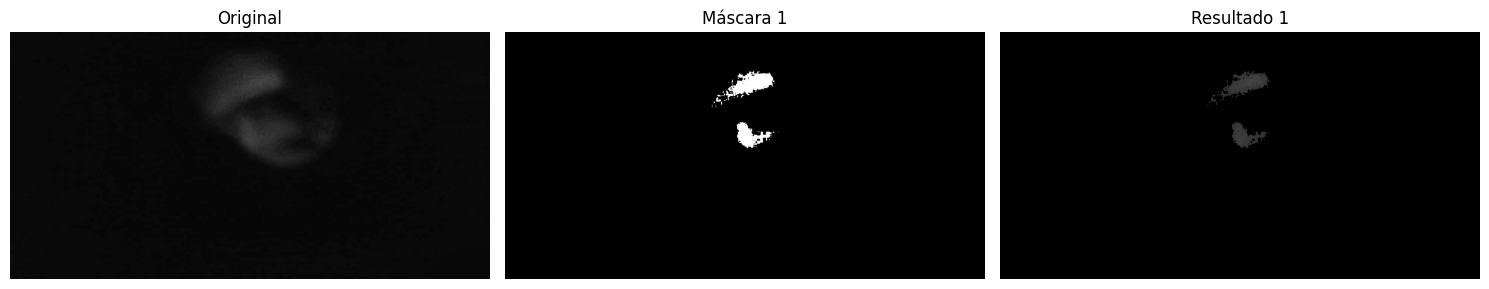

Al ajustar los umbrales en los canales RGB, especialmente aumentando el rango en el canal verde, la máscara logra detectar correctamente la zona del cuerpo del loro. El fondo oscuro queda mayormente excluido, lo que indica que la segmentación es efectiva. Sin embargo, pueden aparecer pequeñas detecciones en otras zonas con colores similares, como áreas amarillas o iluminadas, lo que evidencia una limitación del método basado en RGB. Aun así, la estrategia resulta adecuada como primera aproximación para segmentar el color verde.


In [42]:
r_min, r_max = 50, 255
g_min, g_max = 50, 255
b_min, b_max = 50, 255

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()

observacion_estrategia = (
    "Al ajustar los umbrales en los canales RGB, especialmente aumentando el rango en el canal verde, "
    "la máscara logra detectar correctamente la zona del cuerpo del loro. "
    "El fondo oscuro queda mayormente excluido, lo que indica que la segmentación es efectiva. "
    "Sin embargo, pueden aparecer pequeñas detecciones en otras zonas con colores similares, "
    "como áreas amarillas o iluminadas, lo que evidencia una limitación del método basado en RGB. "
    "Aun así, la estrategia resulta adecuada como primera aproximación para segmentar el color verde."
)

print(observacion_estrategia)

## Parte 4. Revisá y mejorá

Proponé una segunda estrategia. Puede cambiar solo un parámetro o varios. Después compará ambos resultados y explicá cuál conservarías.

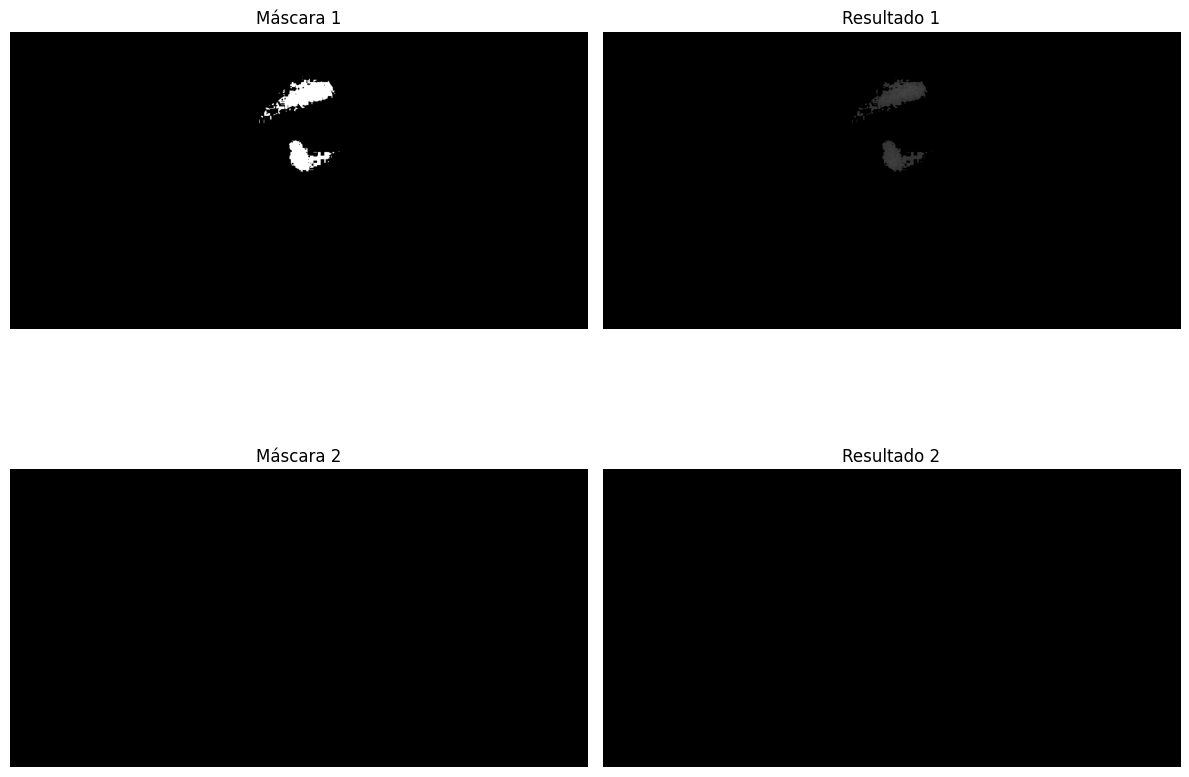

Se probaron dos estrategias de segmentación ajustando los rangos en los canales RGB. En la primera estrategia, con un rango más amplio (50–255), la máscara logra detectar correctamente la zona verde del cuerpo del loro, aunque incluye algo de ruido en regiones con colores similares. En la segunda estrategia, con un rango más restrictivo (90–255), la máscara pierde la mayor parte de la información y no logra detectar correctamente el objeto, ya que muchos píxeles del loro no alcanzan ese nivel en los tres canales simultáneamente. Esto muestra que los valores de color del loro no son tan altos como parecen visualmente y que un rango demasiado estricto elimina información relevante. Por lo tanto, la primera estrategia resulta más adecuada, ya que permite capturar el objeto de interés.


In [43]:
r_min_2, r_max_2 = 90, 255
g_min_2, g_max_2 = 90, 255
b_min_2, b_max_2 = 90, 255

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


comparacion = (
    "Se probaron dos estrategias de segmentación ajustando los rangos en los canales RGB. "
    "En la primera estrategia, con un rango más amplio (50–255), la máscara logra detectar correctamente "
    "la zona verde del cuerpo del loro, aunque incluye algo de ruido en regiones con colores similares. "
    "En la segunda estrategia, con un rango más restrictivo (90–255), la máscara pierde la mayor parte "
    "de la información y no logra detectar correctamente el objeto, ya que muchos píxeles del loro no alcanzan "
    "ese nivel en los tres canales simultáneamente. "
    "Esto muestra que los valores de color del loro no son tan altos como parecen visualmente y que un rango "
    "demasiado estricto elimina información relevante. "
    "Por lo tanto, la primera estrategia resulta más adecuada, ya que permite capturar el objeto de interés."
)

print(comparacion)

## Parte 5. Cierre escrito

Respondé con tus palabras:

1. ¿Qué color intentaste segmentar?
2. ¿Qué canales te dieron la pista más útil?
3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia?
4. ¿Qué limitaciones encontraste en este método?
5. Si tuvieras más tiempo, ¿qué mejorarías?

Respuestas:

1. Intenté segmentar el color verde del cuerpo del loro.

2. El canal que dio la pista más útil fue el canal verde (G), ya que esa zona del loro presenta valores más altos en ese canal en comparación con los otros. Esto permitió identificar una diferencia clara respecto al fondo oscuro.

3. En la primera estrategia utilicé un rango más amplio (50–255) en los tres canales, lo que permitió detectar correctamente el loro pero incluyendo algo de ruido. En la segunda estrategia probé un rango más restrictivo (90–255), pero este resultó demasiado estricto y no logró detectar el objeto. Por eso decidí conservar la primera estrategia como la más adecuada.

4. El método RGB tiene limitaciones porque los colores pueden superponerse en los canales. Por ejemplo, otros colores como el amarillo o zonas iluminadas también pueden tener valores altos en el canal verde, generando falsas detecciones. Además, la iluminación influye en los valores de los píxeles y puede afectar la segmentación.

5. Si tuviera más tiempo, probaría segmentar en el espacio de color HSV, ya que permite separar mejor el tono del brillo y sería más robusto para detectar el color verde. También aplicaría operaciones morfológicas para limpiar la máscara y mejorar la continuidad de la región segmentada.


### Lista de control antes de entregar

- Mostré la imagen original.
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.
